# Sensitivity analysis of intermediate variables uncertainty to input errors : contribution of carbon inputs estimation method to uncertainty of carbon inputs 

### We will take the example of winter wheat


In [2]:
from scipy.stats import iqr
import os
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.stats import gamma
import time
import seaborn as sns
from IPython.display import display, Math


# DATA

### Default values from Clivot et al. (2023) for winter wheat, required to compute carbon inputs

Clivot et al. (2023) : https://doi.org/10.57745/MEQQIX

In [3]:
### Default values from Clivot et al. (2023) for winter wheat 

# Variables considered certain
kag    = 0.217   # Humification coefficient for above-ground biomass
kbg    = 0.4     # Humification coefficient for below-ground biomass

beta   = 0.960   # Coefficient for root distribution 
depth  = 30      # Depth considered in simulation, in (cm)

Ccag   = 0.45    # Carbon concentration in above-groud biomass
Ccbg   = 0.4     # Carbon concentration in below-ground biomass

# Variables considered uncertain
mu_HI  = 0.479   # Harvest Index 
mu_SR  = 7.517   # Shoot:Root ratio
mu_Pse = 0.5     # Export factor 


### Constants defined in the paper
A = kag * Ccag
B = 1.65 * Ccbg * kbg * ( 1- pow(beta, depth))


### French regional statistics for yield Agreste et al. (2025) for winter wheat

Agreste et al. (2025) : https://agreste.agriculture.gouv.fr/agreste-web/disaron/SAA-SeriesLongues/detail/

The two csv loaded here correspond to the sheet "COP" of the excel files SAA_2010-2024_définitives_donnees_departementales.xlsx and SAA_2010-2024_définitives_donnees_regionales.xlsx downloaded at the Agreste site (https://agreste.agriculture.gouv.fr/agreste-web/disaron/SAA-SeriesLongues/detail/).



In [4]:
### Load the data for winter wheat (=soft wheat)


## French administrative department level : the level used in the paper for Large-scale error scenario
all_Yp_dep = pd.read_csv("../data/SAA_extract_departemental_yield_2010_2024.csv", sep=';')

Yp_soft_W_wheat_dep = all_Yp_dep[all_Yp_dep['LIB_SAA']=="01 - Blé tendre d'hiver et épeautre"]

arr_Yp_soft_W_wheat_dep = Yp_soft_W_wheat_dep[['REND_2010', 'REND_2011', 'REND_2012',
       'REND_2013', 'REND_2014', 'REND_2015', 'REND_2016', 'REND_2017',
       'REND_2018', 'REND_2019', 'REND_2020', 'REND_2021', 'REND_2022',
       'REND_2023', 'REND_2024']].to_numpy()

# conversion of yield from qt/ha to t/ha
arr_Yp_soft_W_wheat_dep = arr_Yp_soft_W_wheat_dep/10

# mean yield for winter wheat over 2010-2024 in t/ha for all French departments
mu_Yp_dep = np.nanmean(arr_Yp_soft_W_wheat_dep)

print("Mean yield over 2010-2024 for all French departments", np.round(mu_Yp_dep,decimals=2), 't/ha')
             
             
## French administrative regional level : only as information
all_Yp_reg = pd.read_csv("../data/SAA_extract_regional_yield_2010_2024.csv", sep='\t')

soft_wheat_Yp_reg = all_Yp_reg[all_Yp_reg['LIB_SAA']=="01 - Blé tendre d'hiver et épeautre"]

arr_soft_wheat_Yp_reg = soft_wheat_Yp_reg[['REND_2010', 'REND_2011', 'REND_2012',
       'REND_2013', 'REND_2014', 'REND_2015', 'REND_2016', 'REND_2017',
       'REND_2018', 'REND_2019', 'REND_2020', 'REND_2021', 'REND_2022',
       'REND_2023', 'REND_2024']].to_numpy()

# the first two lines are statistics at national level, so we keep only regional stat
arr_soft_wheat_Yp_reg = arr_soft_wheat_Yp_reg[2:]
# conversion Yp from qt/ha to t/ha
arr_soft_wheat_Yp_reg = arr_soft_wheat_Yp_reg/10
             
# mean yield for winter wheat over 2010-2024 in t/ha for all French regions
mu_Yp_reg = np.nanmean(arr_soft_wheat_Yp_reg)
             
             


Mean yield over 2010-2024 for all French departments 6.17 t/ha


## Error on  HI (Harvest Index), Pse (Export factor), Yp (Dry yield)

We compute the RMSE between QualiAgro measurements and either default value from Clivot et al. (2023) or regional statistics for yield from Agreste et al. (2025).


#### QualiAgro data for measurements :  HI (Harvest Index), Pse (Export factor), Yp (Dry yield)

Fujisaki et al. (2026): https://doi.org/10.57745/WKQHW2

#### Default values for HI and Pse : 

Clivot et al. (2023) : https://doi.org/10.57745/MEQQIX

#### Regional statistics for yield :

Agreste et al. (2025) : https://agreste.agriculture.gouv.fr/agreste-web/disaron/SAA-SeriesLongues/detail/



### Harvest index data (HI)

In [5]:
### From Qualiagro HI measurements for winter wheat

HI_data = pd.read_csv('../data/HI_wheat_measured_Qualiagro.csv', sep='\t')


## Defaul value from Clivot et al. (2023) mu_HI = 0.479 for winter wheat
# We compute the RMSE of measured HI with defaul value of HI

rmse_HI= np.sqrt(np.mean((mu_HI - HI_data['HI_mes'].values)**2))

print('HI RMSE :', np.round(rmse_HI,decimals=3))


HI RMSE : 0.112


### Yield data

- Column 'Yield_mes' : yield (Yp) from Qualiagro measurements for winter wheat
- Column 'Stat_Agreste_dep' : yield (Yp) from Agreste regional statistics at French administrative department level for winter wheat
- Column 'Stat_Agreste_ref' : yield (Yp) from Agreste regional statistics at French administrative regional level for winter wheat

Since QualiAgro data starts in 1998 and Agreste only in 2010, we took the average Yp the department and region corresponding to QualiAgro (i.e., Yvelines and Ile de France) over the 2010-2024 timeseries for the years missing.


In [6]:
### Yield data

Yp_data = pd.read_csv('../data/Yp_wheat_measured_Qualiagro.csv', sep=',')

# RMSE computed with average departmental Yp in Yvelines (department of QualiAgro site)
rmse_Yp_dep = np.sqrt(np.mean((Yp_data['Stat_Agreste_dep'].values - Yp_data['Yield_mes'].values)**2))

# RMSE computed with average regional Yp in Ile de France (region of QualiAgro site)
rmse_Yp_reg = np.sqrt(np.mean((Yp_data['Stat_Agreste_reg'].values - Yp_data['Yield_mes'].values)**2))

print('Yield RMSE calculated at French administrative department level :', np.round(rmse_Yp_dep,decimals=2),'t/ha')
print('Yield RMSE calculated at French administrative Regional level :', np.round(rmse_Yp_reg,decimals=2),'t/ha')

Yield RMSE calculated at French administrative department level : 2.34 t/ha
Yield RMSE calculated at French administrative Regional level : 2.48 t/ha


### Export factor data (Pse)

- Column 'Pse_mes' : export factor (Pse) from Qualiagro measurements for winter wheat


In [7]:
### From Qualiagro Pse measurement for winter wheat and barley

Pse_data = pd.read_csv('../data/Pse_mes_vs_def.csv', sep=',')

# We compute the rmse of measured Pse with defaul value of Pse (from Clivot et al. 2023)
## defaul value from Clivot et al. (2023) mu_Pse = 0.5 for wheat/barley 
rmse_Pse = np.sqrt(np.mean((mu_Pse- Pse_data['Pse_mes'].values)**2))


print('Pse RMSE :', np.round(rmse_Pse,decimals=2))


Pse RMSE : 0.24


## Biomass values, mean and error

- Yp  : Dry yield
- DAM : Dry above ground biomass
- DBM : Dry below ground biomass
- HI  : Harvest Index
- SR  : Shoot:root ratio
- Pse : Export factor


We use the mean yield (Yp) computed over the 2010-2024 period over all French department.

We derive the total total biomass (above and below ground) from the yield in order to have the same carbon inputs estimated with both methods, either using yield or total biomass. However, since the error on each variable will be different, the uncertainty of carbon inputs is different in both methods. 

The values of HI, Pse and SR are default values from Clivot et al. (2023) defined above. The error on HI and Pse are the RMSE computed with QualiAgro measurements above. The error on SR is the standard deviation reported in Bolinder et al. (2007) for winter wheat in Canada (their table 3), that has mean_SR = 6, which is closer to SR in France than the one in USA in Bolinder (~1).

The error of Yp corresponds to the RMSE computed between average yield in Yvelines from regional statistics (Agreste et al. 2025) and yield measurement from QualiAgro site, cf above.


The error on DAM corresponds to the RMSE of AgriCarbon-EO model evaluated against in-situ biomass data (Wijmer et al. 2024). The error on DBM here corresponds to sigma_DAM/mu_SR.



In [8]:
### Mean values

mu_Yp  = mu_Yp_dep             # Mean Dry yield in t/ha

mu_DAM = mu_Yp / mu_HI         # Mean Dry Above-ground Biomass in t/ha

mu_DBM = mu_Yp/ (mu_SR*mu_HI)  # Mean Dry Below-ground Biomass in t/ha


### Error values

sigma_Yp  = rmse_Yp_dep

sigma_HI  = rmse_HI

sigma_SR  = 1.2  # std in Bolinder et al. (2007)

sigma_DAM = 2.1 # RMSE from ACEO validation in Wijmer et al. (2024)

sigma_DBM = sigma_DAM/mu_SR  

rho_DAM_DBM = 0.5 # correlation coefficient between DAM and DBM
cov_DAM_DBM = rho_DAM_DBM * sigma_DAM * sigma_DBM # covariance between DAM and DBM

sigma_Pse = rmse_Pse


In [9]:
display(Math(rf'\textbf{{Mean values used in the paper :}}'))
display(Math(rf'\text{{Mean dry yield : }} \mu_{{Yp}} = {np.round(mu_Yp, 2)} \text{{ t/ha}}'))
display(Math(rf'\text{{Mean dry above-ground biomass : }} \mu_{{DAM}} = {np.round(mu_DAM, 2)} \text{{ t/ha}}'))
display(Math(rf'\text{{Mean dry below-ground biomass : }} \mu_{{DBM}} = {np.round(mu_DBM, 2)} \text{{ t/ha}}'))
display(Math(rf'\text{{Mean harvest-index HI : }} \mu_{{HI}} = {np.round(mu_HI, 3)}'))
display(Math(rf'\text{{Mean shoot-to-root ratio SR : }} \mu_{{SR}} = {np.round(mu_SR, 2)}'))
display(Math(rf'\text{{Mean export factor Pse : when straw exported }} \mu_{{Pse}} = {np.round(mu_Pse, 2)}, \text{{otherwise }} \mu_{{Pse}} = 1 '))

display(Math(rf'\textbf{{Error values used in the paper :}}'))


display(Math(rf'\text{{Error on dry yield (Large-scale scenario): }} \sigma_{{Yp}} = {np.round(sigma_Yp, 2)} \text{{ t/ha}}'))
display(Math(rf'\text{{Error on dry above-ground biomass (Field-scale scenario): }} \sigma_{{DAM}} = {np.round(sigma_DAM, 2)} \text{{ t/ha}}'))
display(Math(rf'\text{{Error on dry below-ground biomass (Field-scale scenario): }} \sigma_{{DBM}} = {np.round(sigma_DBM, 2)} \text{{ t/ha}}'))
display(Math(rf'\text{{Error on harvest-index HI : }} \sigma_{{HI}} = {np.round(sigma_HI, 3)}'))
display(Math(rf'\text{{Error on shoot-to-root ratio SR : }} \sigma_{{SR}} = {np.round(sigma_SR, 2)}'))

display(Math(rf'\text{{Error on export factor Pse : when straw exported }} \sigma_{{Pse}} = {np.round(sigma_Pse, 2)}, \text{{otherwise }} \sigma_{{Pse}} = 0 '))



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Functions to compute expected carbon inputs and its uncertainty

We derive the uncertainty of carbon inputs with Taylor 1st order, either using (i) the yield average method or (ii) the total biomass method. As a reminder, constants A and B are considered not uncertain and are defined in the begining as 
- A = kag * Ccag 
- B = 1.65 * Ccbg * kbg * ( 1- pow(beta, depth))

In [10]:
### Expected carbon inputs humified :

## Function to compute carbon inputs with method (i) using Yp : Eq. (2.5) and (2.6)
def Cinput_Yp(mu_Yp, mu_HI, mu_SR, mu_Pse):
    term1 = A * mu_Pse * mu_Yp*((1 - mu_HI) / mu_HI) 
    term2 = B * mu_Yp / (mu_SR * mu_HI)
    return term1 + term2 

## Function to compute carbon inputs with method (ii) using DAM and DBM : Eq. (2.7) and (2.8)
def Cinput_DAM(mu_HI, mu_DAM, mu_DBM, mu_Pse):
    term1 =  A * mu_Pse * (1 - mu_HI)* mu_DAM
    term2 =  B * mu_DBM
    return term1 + term2 

### Uncertainty on carbon inputs humified : 

## Function to compute the variance of carbon inputs with method (i) using Yp : Eq. (2.9)
def var_Cinput_Yp(sigma_Yp, sigma_HI, sigma_SR, mu_HI, mu_SR, mu_Pse, sigma_Pse):
    term1 = (A * mu_Pse * ((1 - mu_HI) / mu_HI) + B * (1 / (mu_SR * mu_HI)))**2 * sigma_Yp**2
    term2 = (B * mu_Yp / (mu_SR * mu_HI**2) + A * mu_Pse * mu_Yp / mu_HI**2)**2 * sigma_HI**2
    term3 = B**2 * (mu_Yp / (mu_SR**2 * mu_HI))**2 * sigma_SR**2
    term4 = (A*mu_Yp * ((1 - mu_HI) / mu_HI))**2 *sigma_Pse**2
    return term1 + term2 + term3 + term4

## Function to compute the variance of carbon inputs with method (ii) using DAM and DBM : Eq. (2.10)
def var_Cinput_DAM(mu_DAM, mu_DBM, sigma_DAM, sigma_HI, sigma_DBM, mu_HI, cov_DAM_DBM, mu_Pse, sigma_Pse):
    term1 = (A * mu_Pse * (1 - mu_HI))**2 * sigma_DAM**2
    term2 = (A* mu_Pse * mu_DAM)**2 * sigma_HI**2
    term3 = B**2 * sigma_DBM**2
    term4 = 2 * A * B * mu_Pse * (1 - mu_HI) * cov_DAM_DBM
    term5 = (A*mu_DAM*(1-mu_HI))**2 * sigma_Pse**2
    return term1 + term2 + term3 + term4 + term5
    

# RESULTS

## Application with straw export (mu_Pse=0.5)

In [11]:
mu_Pse    = 0.5 # Default value from Clivot et al. (2023) for wheat
sigma_Pse = rmse_Pse

fix_Cinp_Yp = Cinput_Yp(mu_Yp, mu_HI, mu_SR, mu_Pse)
fix_Cinp_DAM = Cinput_DAM(mu_HI, mu_DAM, mu_DBM, mu_Pse)
fix_sigma_Cinp_Yp = np.sqrt(var_Cinput_Yp(sigma_Yp, sigma_HI, sigma_SR, mu_HI, mu_SR, mu_Pse, sigma_Pse))
fix_sigma_Cinp_DAM = np.sqrt(var_Cinput_DAM(mu_DAM, mu_DBM, sigma_DAM, sigma_HI, sigma_DBM, mu_HI, cov_DAM_DBM, mu_Pse, sigma_Pse))

rel_sigma_Cinp_Yp = fix_sigma_Cinp_Yp*100/fix_Cinp_Yp
rel_sigma_Cinp_DAM = fix_sigma_Cinp_DAM*100/fix_Cinp_DAM

In [12]:
display(Math(rf'\textbf{{Carbon inputs estimation using Yp :}}'))
display(Math(rf'\text{{Expected carbon inputs humified }} \mu_I = {np.round(fix_Cinp_Yp, 2)}\ \text{{tC/ha}}'))
display(Math(rf'\text{{Absolute uncertainty of carbon inputs humified }} \sigma_I = {np.round(fix_sigma_Cinp_Yp,decimals=2)}\ \text{{tC/ha}}'))
display(Math(
    rf'\text{{Relative uncertainty of carbon inputs humified }} '
    rf'\frac{{\sigma_I}}{{\mu_I}} = {np.round(rel_sigma_Cinp_Yp, 1)}\%'
))


display(Math(rf'\textbf{{Carbon inputs estimation using DAM and DBM :}}'))
display(Math(rf'\text{{Expected carbon inputs humified }} \mu_I = {np.round(fix_Cinp_DAM,2)}\ \text{{tC/ha}}'))
display(Math(rf'\text{{Absolute uncertainty of carbon inputs humified }} \sigma_I = {np.round(fix_sigma_Cinp_DAM, decimals=2)}\ \text{{tC/ha}}'))
display(Math(
    rf'\text{{Relative uncertainty of carbon inputs humified }} '
    rf'\frac{{\sigma_I}}{{\mu_I}} = {np.round(rel_sigma_Cinp_DAM, 1)}\%'
))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Application with no straw export (mu_Pse=1, sigma_Pse=0)

In [13]:
mu_Pse    = 1
sigma_Pse = 0

fix_Cinp_Yp = Cinput_Yp(mu_Yp, mu_HI, mu_SR, mu_Pse)
fix_Cinp_DAM = Cinput_DAM(mu_HI, mu_DAM, mu_DBM, mu_Pse)
fix_sigma_Cinp_Yp = np.sqrt(var_Cinput_Yp(sigma_Yp, sigma_HI, sigma_SR, mu_HI, mu_SR, mu_Pse, sigma_Pse))
fix_sigma_Cinp_DAM = np.sqrt(var_Cinput_DAM(mu_DAM, mu_DBM, sigma_DAM, sigma_HI, sigma_DBM, mu_HI, cov_DAM_DBM, mu_Pse, sigma_Pse))

rel_sigma_Cinp_Yp = fix_sigma_Cinp_Yp*100/fix_Cinp_Yp
rel_sigma_Cinp_DAM = fix_sigma_Cinp_DAM*100/fix_Cinp_DAM

In [14]:
display(Math(rf'\textbf{{Carbon inputs estimation using Yp :}}'))
display(Math(rf'\text{{Expected carbon inputs humified }} \mu_I = {np.round(fix_Cinp_Yp, 2)}\ \text{{tC/ha}}'))
display(Math(rf'\text{{Absolute uncertainty of carbon inputs humified }} \sigma_I = {np.round(fix_sigma_Cinp_Yp,decimals=2)}\ \text{{tC/ha}}'))
display(Math(
    rf'\text{{Relative uncertainty of carbon inputs humified }} '
    rf'\frac{{\sigma_I}}{{\mu_I}} = {np.round(rel_sigma_Cinp_Yp, 1)}\%'
))


display(Math(rf'\textbf{{Carbon inputs estimation using DAM and DBM :}}'))
display(Math(rf'\text{{Expected carbon inputs humified }} \mu_I = {np.round(fix_Cinp_DAM,2)}\ \text{{tC/ha}}'))
display(Math(rf'\text{{Absolute uncertainty of carbon inputs humified }} \sigma_I = {np.round(fix_sigma_Cinp_DAM, decimals=2)}\ \text{{tC/ha}}'))
display(Math(
    rf'\text{{Relative uncertainty of carbon inputs humified }} '
    rf'\frac{{\sigma_I}}{{\mu_I}} = {np.round(rel_sigma_Cinp_DAM, 1)}\%'
))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# We now vary sigma DAM and sigma Yp (no straw export)

We keep the assumption of no straw export (mu_Pse=1 and sigma_Pse=0)


In [15]:
# Expected carbon inputs
mu_Pse    = 1
sigma_Pse = 0
I_Yp = Cinput_Yp(mu_Yp, mu_HI, mu_SR, mu_Pse)
I_DAM = Cinput_DAM(mu_HI, mu_DAM, mu_DBM, mu_Pse)

### For method using Yp


/tmp/ipykernel_131249/482192420.py:32: UserWarning: No contour levels were found within the data range.
  plt.contour(sigma_HI_vals, sigma_Yp_vals, std_Cinp_Yp, levels=[0], colors='black', linewidths=2)


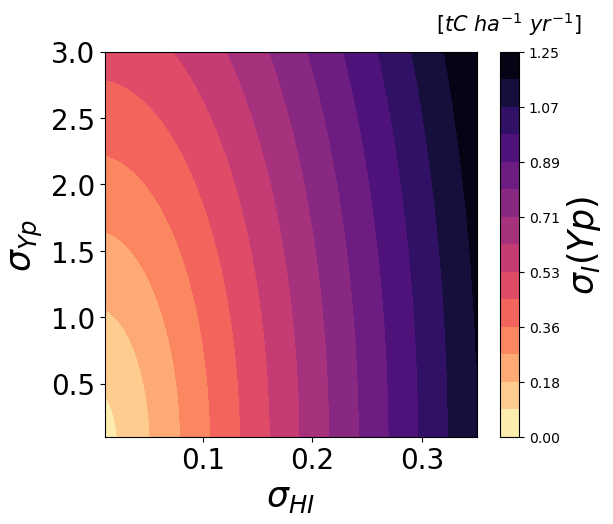

/tmp/ipykernel_131249/482192420.py:56: UserWarning: No contour levels were found within the data range.
  plt.contour(sigma_HI_vals, sigma_Yp_vals, err_Yp, levels=[0], colors='black', linewidths=2)
/tmp/ipykernel_131249/482192420.py:81: UserWarning: No contour levels were found within the data range.
  plt.contour(sigma_HI_vals, sigma_Yp_vals, err_Yp, levels=[0], colors='black', linewidths=2)


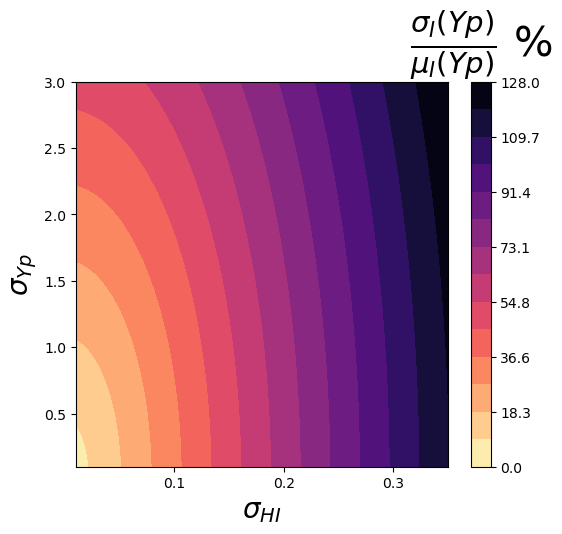

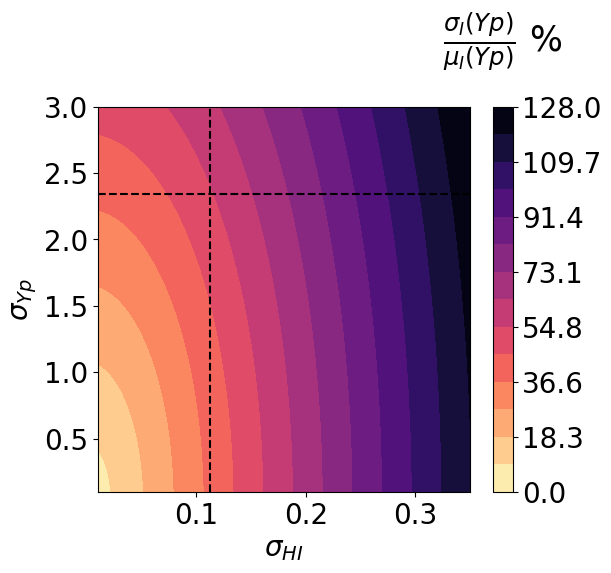

In [16]:
### Effect of sigma YP and sigma HI on sigma Cinp

# Grids with varying HI and Yp

sigma_HI_vals = np.linspace(0.01, 0.35, 200)
sigma_Yp_vals = np.linspace(0.1, 3, 200)

SIGMA_HI, SIGMA_Yp = np.meshgrid(sigma_HI_vals, sigma_Yp_vals)

# Compute uncertainty of carbon inputs on the grid
std_Cinp_Yp = np.sqrt(var_Cinput_Yp(
    SIGMA_Yp, SIGMA_HI, sigma_SR,
    mu_HI, mu_SR, mu_Pse, sigma_Pse))



# Heatmap for the absolute uncertainty sigma_Cinp using Yp
max_abs = np.max(np.abs(std_Cinp_Yp))

plt.figure(figsize=(6,5))
plt.tick_params(axis='both', which='both', color='black', labelcolor='black')
levels = np.linspace(0, max_abs, 15)
im = plt.contourf(
    sigma_HI_vals, sigma_Yp_vals, std_Cinp_Yp,
    levels=levels, cmap="magma_r"
)
cbar = plt.colorbar(im)
cbar.set_label(label="$\sigma_{I}(Yp)$",
               size=25, weight='bold')
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
cbar.ax.set_title(r"[$tC~ha^{-1}~yr^{-1}$]", fontsize=15,pad=15)
plt.contour(sigma_HI_vals, sigma_Yp_vals, std_Cinp_Yp, levels=[0], colors='black', linewidths=2)
ax = plt.gca()
ax.tick_params(axis='both', labelsize=20, colors='black')
plt.xlabel("$\sigma_{HI}$", fontsize=25)
plt.ylabel("$\sigma_{Yp}$", fontsize=25)
plt.show()

# Heatmap for the relative uncertainty sigma_Cinp/mu_Cinp using Yp 
err_Yp =100*std_Cinp_Yp/I_Yp 

# palette centrée sur zéro
max_abs = np.max(np.abs(err_Yp))
plt.figure(figsize=(6,5))
levels = np.linspace(0, max_abs, 15)

im = plt.contourf(
    sigma_HI_vals, sigma_Yp_vals, err_Yp,
    levels=levels, cmap="magma_r"
)

cbar = plt.colorbar(im)

cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
cbar.ax.set_title(r"$\frac{\sigma_{I}(Yp)}{\mu_I(Yp)}$ %", fontsize=30)
plt.contour(sigma_HI_vals, sigma_Yp_vals, err_Yp, levels=[0], colors='black', linewidths=2)
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.xlabel("$\sigma_{HI}$", fontsize=20)
plt.ylabel("$\sigma_{Yp}$", fontsize=20)

# Heatmap for the relative uncertainty sigma_Cinp/mu_Cinp using Yp,
# with dashed lines representing errors values from scenarios (Fig. 6a)

plt.figure(figsize=(6,5))
levels = np.linspace(0, max_abs, 15)

im = plt.contourf(
    sigma_HI_vals, sigma_Yp_vals, err_Yp,
    levels=levels, cmap="magma_r"
)

cbar = plt.colorbar(im)

cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
cbar.ax.set_title(
    r"$\frac{\sigma_{I}(Yp)}{\mu_I(Yp)}$ %",
    fontsize=25,
    pad=40   # increase this value to move it higher
)
plt.contour(sigma_HI_vals, sigma_Yp_vals, err_Yp, levels=[0], colors='black', linewidths=2)
plt.hlines(sigma_Yp, 0.01, 0.35,linestyles='--', color='black', label='RMSE_dep_level')

plt.vlines(sigma_HI, 0.1, 3,linestyles='--', color='black', label='RMSE HI')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.xlabel("$\sigma_{HI}$", fontsize=20)
plt.ylabel("$\sigma_{Yp}$", fontsize=20)
#plt.legend()
plt.show()

### For method using DAM and DBM


/tmp/ipykernel_131249/1981671584.py:33: UserWarning: No contour levels were found within the data range.
  plt.contour(sigma_HI_vals, sigma_DAM_vals, std_Cinp_DAM, levels=[0], colors='black', linewidths=2)


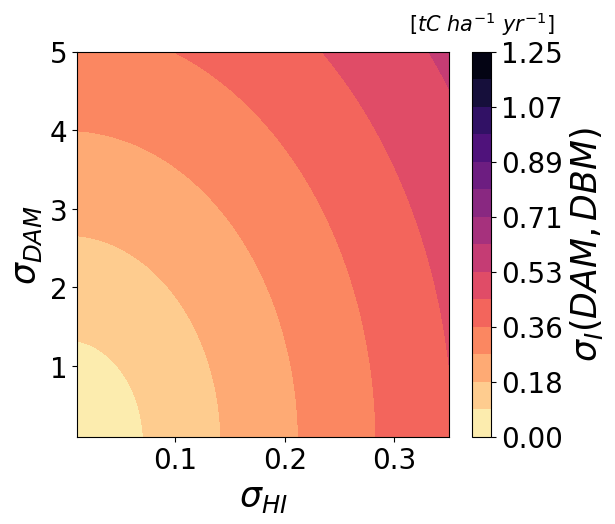

/tmp/ipykernel_131249/1981671584.py:64: UserWarning: No contour levels were found within the data range.
  plt.contour(sigma_HI_vals, sigma_DAM_vals, err_DAM, levels=[0], colors='black', linewidths=2)
/tmp/ipykernel_131249/1981671584.py:94: UserWarning: No contour levels were found within the data range.
  plt.contour(sigma_HI_vals, sigma_DAM_vals, err_DAM, levels=[0], colors='black', linewidths=2)


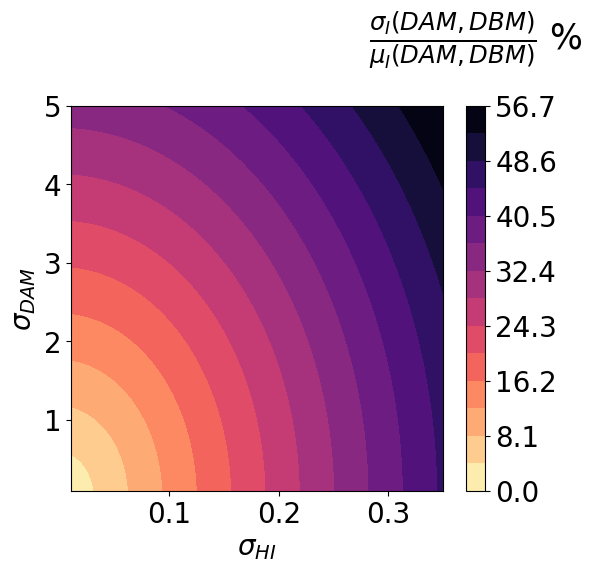

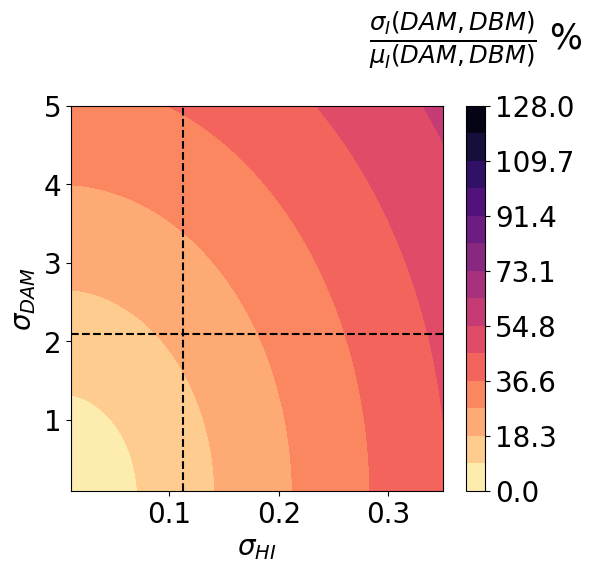

In [17]:
### Effect of sigma DAM, DBM and sigma HI on sigma Cinp

# Grids with varying DAM, DBM and HI

sigma_DAM_vals = np.linspace(0.1, 5, 100)
sigma_HI_vals = np.linspace(0.01, 0.35, 200)

SIGMA_HI, SIGMA_DAM = np.meshgrid(sigma_HI_vals, sigma_DAM_vals)

SIGMA_DBM = SIGMA_DAM/mu_SR
COV_DAM_DBM = rho_DAM_DBM*SIGMA_DAM*SIGMA_DBM

# Compute uncertainty of carbon inputs on the grid
std_Cinp_DAM = np.sqrt(var_Cinput_DAM(mu_DAM,mu_DBM, SIGMA_DAM, SIGMA_HI, SIGMA_DBM, mu_HI, COV_DAM_DBM,mu_Pse, sigma_Pse))

# Heatmap for the absolute uncertainty sigma_Cinp using DAM and DBM
max_abs = np.max(np.abs(std_Cinp_Yp)) # We get the max of the uncertainty using Yp to have the same axis limit

plt.figure(figsize=(6,5))
plt.tick_params(axis='both', which='both', color='black', labelcolor='black')
levels = np.linspace(0, max_abs, 15)

im = plt.contourf(
    sigma_HI_vals, sigma_DAM_vals, std_Cinp_DAM,
    levels=levels, cmap="magma_r"
)

cbar = plt.colorbar(im)
cbar.set_label(label="$\sigma_{I}(DAM,DBM)$",
               size=25, weight='bold')
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
cbar.ax.set_title(r"[$tC~ha^{-1}~yr^{-1}$]", fontsize=15,pad=15)
plt.contour(sigma_HI_vals, sigma_DAM_vals, std_Cinp_DAM, levels=[0], colors='black', linewidths=2)
ax = plt.gca()
ax.tick_params(axis='both', labelsize=20, colors='black')
plt.xlabel("$\sigma_{HI}$", fontsize=25)
plt.ylabel("$\sigma_{DAM}$", fontsize=25)
plt.show()


# Heatmap for the relative uncertainty sigma_Cinp/mu_Cinp using DAM and DBM 
err_DAM =100*std_Cinp_DAM/I_DAM 

# we keep the maximum of the uncertainty using DAM and DBM to observe its real max
max_abs = np.max(np.abs(err_DAM))

plt.figure(figsize=(6,5))
levels = np.linspace(0, max_abs, 15)

im = plt.contourf(
    sigma_HI_vals, sigma_DAM_vals, err_DAM,
    levels=levels, cmap="magma_r"
)

cbar = plt.colorbar(im)

cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
cbar.ax.set_title(r"$\frac{\sigma_{I}(DAM,DBM)}{\mu_{I}(DAM,DBM)}$ %", fontsize=30)
cbar.ax.set_title(
    r"$\frac{\sigma_{I}(DAM,DBM)}{\mu_{I}(DAM,DBM)}$ %",
    fontsize=25,
    pad=40   # increase this value to move it higher
)
plt.contour(sigma_HI_vals, sigma_DAM_vals, err_DAM, levels=[0], colors='black', linewidths=2)

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.xlabel("$\sigma_{HI}$", fontsize=20)
plt.ylabel("$\sigma_{DAM}$", fontsize=20)

# Heatmap for the relative uncertainty sigma_Cinp/mu_Cinp using DAM and DBM 
# with dashed lines representing errors values from scenarios (Fig. 6b)

plt.figure(figsize=(6,5))
# we put the max of uncertainty of Yp method to keep the same axis limit in both figures 6a and 6b
max_abs = np.max(np.abs(err_Yp))

levels = np.linspace(0, max_abs, 15)

im = plt.contourf(
    sigma_HI_vals, sigma_DAM_vals, err_DAM,
    levels=levels, cmap="magma_r"
)

cbar = plt.colorbar(im)

cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
cbar.ax.set_title(
    r"$\frac{\sigma_{I}(DAM,DBM)}{\mu_{I}(DAM,DBM)}$ %",
    fontsize=25,
    pad=40   # increase this value to move it higher
)

plt.contour(sigma_HI_vals, sigma_DAM_vals, err_DAM, levels=[0], colors='black', linewidths=2)
plt.hlines(sigma_DAM, 0.01, 0.35,linestyles='--', color='black')
plt.vlines(sigma_HI, 0.1, 5,linestyles='--', color='black')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.xlabel("$\sigma_{HI}$", fontsize=20)
plt.ylabel("$\sigma_{DAM}$", fontsize=20)
plt.show()


# DISCUSSION

## Carbon inputs uncertainty when all variables are uncertain

We also use Taylor 1st order to derive the uncertainty expression of carbon inputs, but all variables and coefficient are uncertain, cf Eq. A.6 and A.11 in the paper.

In [18]:
### Uncertainty on carbon inputs humified : 

## Function to compute the variance of carbon inputs with method (i) using Yp : Eq. (A.6)
def var_Cinput_Yp_all_uncertain(sigma_Yp, sigma_HI, sigma_SR, mu_HI, mu_SR, mu_Pse, sigma_Pse):
    term1 = (A * mu_Pse * ((1 - mu_HI) / mu_HI) + B * (1 / (mu_SR * mu_HI)))**2 * sigma_Yp**2
    term2 = (B * mu_Yp / (mu_SR * mu_HI**2) + A * mu_Pse * mu_Yp / mu_HI**2)**2 * sigma_HI**2
    term3 = B**2 * (mu_Yp / (mu_SR**2 * mu_HI))**2 * sigma_SR**2
    term4 = (A*mu_Yp * ((1 - mu_HI) / mu_HI))**2 *sigma_Pse**2
    term5 = (mu_Pse*mu_Yp*kag*((1 - mu_HI) / mu_HI))**2 * sigma_Ccag**2
    term6 = (Ccag*mu_Pse*mu_Yp*((1 - mu_HI) / mu_HI))**2 *sigma_kag**2
    term7 = (1.65*(1- pow(beta, depth))*(mu_Yp / (mu_SR * mu_HI)) *kbg)**2 *sigma_Ccbg**2
    term8 = (1.65 * Ccbg * ( 1- pow(beta, depth))* (mu_Yp / (mu_SR * mu_HI)))**2 * sigma_kbg**2
    term9 = (-1.65 * Ccbg*(mu_Yp / (mu_SR * mu_HI))*depth* pow(beta, depth-1))**2 *sigma_beta**2
    return term1 + term2 + term3 + term4 + term5 + term6 + term7 + term8 + term9

## Function to compute the variance of carbon inputs with method (ii) using DAM and DBM : Eq. (A.11)
def var_Cinput_DAM_all_uncertain(mu_DAM, mu_DBM, sigma_DAM, sigma_HI, sigma_DBM, mu_HI, cov_DAM_DBM, mu_Pse, sigma_Pse):
    term1 = (A * mu_Pse * (1 - mu_HI))**2 * sigma_DAM**2
    term2 = (A* mu_Pse * mu_DAM)**2 * sigma_HI**2
    term3 = B**2 * sigma_DBM**2
    term4 = 2 * A * B * mu_Pse * (1 - mu_HI) * cov_DAM_DBM
    term5 = (A*mu_DAM*(1-mu_HI))**2 * sigma_Pse**2
    term6 = (mu_Pse*kag*mu_DAM*(1-mu_HI))**2 * sigma_Ccag**2
    term7 = (Ccag*mu_Pse*mu_DAM*(1-mu_HI))**2 *sigma_kag**2
    term8 = (1.65*(1- pow(beta, depth))*mu_DBM *kbg)**2 *sigma_Ccbg**2
    term9 = (1.65 * Ccbg * ( 1- pow(beta, depth))* mu_DBM)**2 * sigma_kbg**2
    term10 = (-1.65 * Ccbg*mu_DBM*depth* pow(beta, depth-1))**2 *sigma_beta**2
    return term1 + term2 + term3 +term4 + term5 + term6 + term7 + term8 + term9 + term10


### Application for straw export (mu_Pse=0.5 and sigma_Pse=0.24)

The result application serve only as illustration, the values of the error would need more investigation to have more realistics values as explained in the paper. 

Ma et al. (2018) : https://doi.org/10.5194/bg-15-693-2018

In [19]:
# Error values for variables previously considered certain. 
sigma_Ccag = 0.0338 # for all crops leaves in Ma et al. (2018) (stem is 0.0315)

sigma_Ccbg = 0.0523 # for all crop root in Ma et al. (2018)

sigma_kag = 0.066218 # std from all crops values in Clivot et al. (2023)

err_rel_10 = 0.1 # we asumme 10% of relative error. 
sigma_kbg = kbg * err_rel_10  

err_rel_1 = 0.01 # we asumme 1% of relative error.
sigma_beta = beta* err_rel_1 


In [20]:
mu_Pse    = 0.5 # Default value from Clivot et al. (2023) for wheat
sigma_Pse = rmse_Pse

fix_Cinp_Yp = Cinput_Yp(mu_Yp, mu_HI, mu_SR, mu_Pse)
fix_Cinp_DAM = Cinput_DAM(mu_HI, mu_DAM, mu_DBM, mu_Pse)
sigma_Cinp_Yp_all_uncertain = np.sqrt(var_Cinput_Yp_all_uncertain(sigma_Yp, sigma_HI, sigma_SR, mu_HI, mu_SR, mu_Pse, sigma_Pse))
sigma_Cinp_DAM_all_uncertain = np.sqrt(var_Cinput_DAM_all_uncertain(mu_DAM,mu_DBM, sigma_DAM, sigma_HI, sigma_DBM, mu_HI,cov_DAM_DBM,mu_Pse, sigma_Pse))

rel_sigma_Cinp_Yp_all_uncertain = sigma_Cinp_Yp_all_uncertain*100/fix_Cinp_Yp
rel_sigma_Cinp_DAM_all_uncertain = sigma_Cinp_DAM_all_uncertain*100/fix_Cinp_DAM



In [21]:
display(Math(rf'\textbf{{Carbon inputs estimation using Yp :}}'))
display(Math(rf'\text{{Expected carbon inputs humified }} \mu_I = {np.round(fix_Cinp_Yp, 2)}\ \text{{tC/ha}}'))
display(Math(rf'\text{{Absolute uncertainty of carbon inputs humified }} \sigma_I = {np.round(sigma_Cinp_Yp_all_uncertain,decimals=2)}\ \text{{tC/ha}}'))
display(Math(
    rf'\text{{Relative uncertainty of carbon inputs humified }} '
    rf'\frac{{\sigma_I}}{{\mu_I}} = {np.round(rel_sigma_Cinp_Yp_all_uncertain, 1)}\%'
))


display(Math(rf'\textbf{{Carbon inputs estimation using DAM and DBM :}}'))
display(Math(rf'\text{{Expected carbon inputs humified }} \mu_I = {np.round(fix_Cinp_DAM,2)}\ \text{{tC/ha}}'))
display(Math(rf'\text{{Absolute uncertainty of carbon inputs humified }} \sigma_I = {np.round(sigma_Cinp_DAM_all_uncertain, decimals=2)}\ \text{{tC/ha}}'))
display(Math(
    rf'\text{{Relative uncertainty of carbon inputs humified }} '
    rf'\frac{{\sigma_I}}{{\mu_I}} = {np.round(rel_sigma_Cinp_DAM_all_uncertain, 1)}\%'
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## Uncertainty on carbon input from organic amendment



In [22]:
### Expected carbon inputs humified from organic amendment
def C_OA_hum(dose,
    dm,
    c_content_oa,
    h_oa):
    
    return dose*dm*c_content_oa*h_oa
    
### Uncertainty of carbon inputs humified from organic amendment

# We return the variance
def var_C_OA(
    dose,
    dm,
    c_content_oa,
    h_oa,
    sigma_dose,
    sigma_dm,
    sigma_c_content_oa,
    sigma_h_oa
):

    term1 = (dm * c_content_oa * h_oa) ** 2 * sigma_dose**2
    term2 = (dose * c_content_oa * h_oa) ** 2 * sigma_dm**2
    term3 = (dose * dm * h_oa) ** 2 * sigma_c_content_oa**2
    term4 = (dose * dm * c_content_oa) ** 2 * sigma_h_oa**2

    return term1 + term2 + term3 + term4


## Application : We assume an application of manure (no info on specific type)

Clivot et al. (2023) : https://doi.org/10.57745/MEQQIX
Michaud et al. (2025) : https://doi.org/10.1016/j.dib.2025.111585


In [23]:
dose = 10 #t/ha fress matter
sigma_dose = 0.1*dose # we assume 10% of relative error
dm = 0.283 # in % from Michaud et al. (2025)
sigma_dm = 0.202 # in % from Michaud et al. (2025)
c_content_oa = 0.691 # in gC/g DM from Michaud et al. (2025)
sigma_c_content_oa = 0.129 # in gC/g DM  from Michaud et al. (2025)
h_oa = 0.604 # mean humification coefficient for all manure type in Clivot et al. (2023)
sigma_h_oa = 0.082 # std h_oa for all manure type in Clivot et al. (2023)
    
    
COA_hum = C_OA_hum(dose,
    dm,
    c_content_oa,
    h_oa)

sigma_COA_hum = np.sqrt(var_C_OA(
    dose,
    dm,
    c_content_oa,
    h_oa,
    sigma_dose,
    sigma_dm,
    sigma_c_content_oa,
    sigma_h_oa
))


In [24]:
display(Math(rf'\textbf{{Carbon inputs estimation from organic amendment :}}'))
display(Math(rf'\text{{Expected carbon inputs humified from organic amendment}} \mu_I(OA) = {np.round(COA_hum, 2)}\ \text{{tC/ha}}'))
display(Math(rf'\text{{Absolute uncertainty of carbon inputs humified }} \sigma_I(OA) = {np.round(sigma_COA_hum,decimals=2)}\ \text{{tC/ha}}'))


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### If considering the previous carbon inputs estimated from crop residues above (with straw export), and adding the carbon inputs from manure we have : 


In [25]:
### Expected total carbon inputs humified
C_inp_crop = 0.6429182729099039 # carbon inputs humified from crop residues previously found for straw export 
C_inp_tot = COA_hum + C_inp_crop # total carbon inputs humified by adding the carbon inputs from organic amendment

### Uncertainty on carbon inputs humified
fix_sigma_Cinp_Yp= 0.3684446891738308
fix_sigma_Cinp_DAM= 0.19281604486937745

sigma_Cinp_tot_Yp = np.sqrt(sigma_COA_hum**2 + fix_sigma_Cinp_Yp**2)
sigma_Cinp_tot_DAM = np.sqrt(sigma_COA_hum**2 + fix_sigma_Cinp_DAM**2)

rel_sigma_Cinp_tot_Yp = sigma_Cinp_tot_Yp*100/C_inp_tot
rel_sigma_Cinp_tot_DAM = sigma_Cinp_tot_DAM*100/C_inp_tot



In [26]:
display(Math(rf'\textbf{{Total carbon inputs estimation using Yp :}}'))
display(Math(rf'\text{{Expected carbon inputs humified from crop residues and organic amendment}} \mu_I(tot) = {np.round(C_inp_tot, 2)}\ \text{{tC/ha}}'))
display(Math(rf'\text{{Absolute uncertainty of total carbon inputs humified }} \sigma_I(tot) = {np.round(sigma_Cinp_tot_Yp,decimals=2)}\ \text{{tC/ha}}'))
display(Math(
    rf'\text{{Relative uncertainty of total carbon inputs humified }} '
    rf'\frac{{\sigma_I}}{{\mu_I}}(tot) = {np.round(rel_sigma_Cinp_tot_Yp, 1)}\%'
))


display(Math(rf'\textbf{{Total carbon inputs estimation using DAM and DBM :}}'))
display(Math(rf'\text{{Expected carbon inputs humified from crop residues and organic amendment }} \mu_I(tot) = {np.round(C_inp_tot,2)}\ \text{{tC/ha}}'))
display(Math(rf'\text{{Absolute uncertainty of total carbon inputs humified }} \sigma_I(tot) = {np.round(sigma_Cinp_tot_DAM, decimals=2)}\ \text{{tC/ha}}'))
display(Math(
    rf'\text{{Relative uncertainty of total carbon inputs humified }} '
    rf'\frac{{\sigma_I}}{{\mu_I}}(tot) = {np.round(rel_sigma_Cinp_tot_DAM, 1)}\%'
))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# SUPPLEMENTAL MATERIAL, Fig. S1

## Sensitivity of the uncertainty of carbon inputs (sigma_Cinp_DAM) to correlation between the total above and below ground biomass (rho_DAM_DBM)

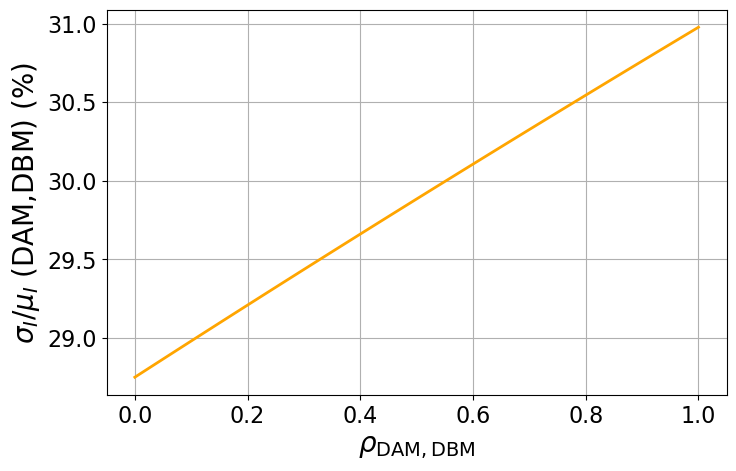

In [30]:
### The previous function directly used the covariance between DAM and DBM (cov_DAM_DBM) as argument function
### We rewrite the function in order to take the correlation coeffitient rho instead

def var_Cinput_DAM_with_rho_DAM_DBM(mu_DAM,mu_DBM, sigma_DAM, sigma_HI, 
                                    sigma_DBM, mu_HI,rho_DAM_DBM,mu_Pse, sigma_Pse):
    term1 = (A * mu_Pse * (1 - mu_HI))**2 * sigma_DAM**2
    term2 = (A* mu_Pse * mu_DAM)**2 * sigma_HI**2
    term3 = B**2 * sigma_DBM**2
    term4 = 2 * A * B * mu_Pse * (1 - mu_HI) * rho_DAM_DBM * sigma_DAM * sigma_DBM
    term5 = (A*mu_DAM*(1-mu_HI))**2 * sigma_Pse**2
    return term1 + term2 + term3 + term4 + term5


def plot_sensitivity_rho(mu_DAM, mu_DBM, sigma_DAM, sigma_HI, sigma_DBM, 
                         mu_HI, mu_Pse, sigma_Pse,
                         rho_min=0, rho_max=1, n_points=100):
    
    # Expected carbon inputs 
    fix_Cinp_DAM = Cinput_DAM(mu_HI, mu_DAM, mu_DBM, mu_Pse)
    
    # The values of correlation coefficient we want to try
    rho_values = np.linspace(rho_min, rho_max, n_points)
    
    # We compute the variance of the carbon inputs for each correlation coefficient rho
    variance_values = [
        var_Cinput_DAM_with_rho_DAM_DBM(
            mu_DAM, mu_DBM, sigma_DAM, sigma_HI, sigma_DBM,
            mu_HI, rho, mu_Pse, sigma_Pse
        )
        for rho in rho_values
    ]
    
    plt.figure(figsize=(8,5))

    plt.plot(
    rho_values,
    100*np.sqrt(variance_values)/fix_Cinp_DAM,
    linewidth=2,
    color='orange'
)

    plt.xlabel(r"$\rho_{\mathrm{DAM,DBM}}$", fontsize=20)

    plt.ylabel(
    r"$\sigma_I/\mu_I$ (DAM,DBM) (%)",
    fontsize=20
)

# Increase tick sizes
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

    plt.grid(True)
    plt.show()
    
    return rho_values, np.array(variance_values)

mu_Pse    = 0.5 # Default value from Clivot et al. (2023) for wheat
sigma_Pse = rmse_Pse
rho_values, var_values = plot_sensitivity_rho(
    mu_DAM=mu_DAM,
    mu_DBM=mu_DBM,
    sigma_DAM=sigma_DAM,
    sigma_HI=sigma_HI,
    sigma_DBM=sigma_DBM,
    mu_HI=mu_HI,
    mu_Pse=mu_Pse,
    sigma_Pse=sigma_Pse
)


## Comparison with the value used in the paper, assuming a correlation coefficient between DAM and DBM rho_DAM_DBM = 0.5

In [31]:
mu_Pse    = 0.5 # Default value from Clivot et al. (2023) for wheat
sigma_Pse = rmse_Pse

# we (re)compute the expected carbon inputs using DAM and DBM
fix_Cinp_DAM = Cinput_DAM(mu_HI, mu_DAM, mu_DBM, mu_Pse)
# we (re)compute the uncertainty of carbon inputs using DAM and DBM and rho_DAM_DBM = 0.5
fix_sigma_Cinp_DAM = np.sqrt(var_Cinput_DAM(mu_DAM, mu_DBM, sigma_DAM, sigma_HI, sigma_DBM, mu_HI, cov_DAM_DBM, mu_Pse, sigma_Pse))
rel_sigma_Cinp_DAM = fix_sigma_Cinp_DAM*100/fix_Cinp_DAM # value used in the paper

max_rel_sigma_Cinp = np.sqrt(np.max(var_values))*100/fix_Cinp_DAM
min_rel_sigma_Cinp = np.sqrt(np.min(var_values))*100/fix_Cinp_DAM

diff_rel_sigma = abs(rel_sigma_Cinp_DAM - max_rel_sigma_Cinp)


In [32]:
display(Math(rf'\textbf{{Relative uncertainty of carbon inputs using DAM and DBM :}}'))
display(Math(rf'\text{{Relative uncertainty of carbon inputs using DAM and DBM with }} \rho_{{DAM,DBM}} = 1 :' rf' \frac{{\sigma_I(max)}}{{\mu_I}} = {np.round(max_rel_sigma_Cinp, 2)}\%'))


display(Math(
    rf'\text{{At worst, error made by assuming  }} \rho_{{DAM,DBM}} =0.5 \text{{ in the paper}}: '
    rf' \text{{diff}} = {np.round(diff_rel_sigma, 2)}\%'
))
display(Math(rf'\text{{Relative uncertainty of carbon inputs using DAM and DBM with }} \rho_{{DAM,DBM}} = 0 :' rf' \frac{{\sigma_I(min)}}{{\mu_I}} = {np.round(min_rel_sigma_Cinp,decimals=2)}\%'))





<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>